In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
TICKERS = {
    "KO": "KO",
    "PEP": "PEP",
}

PERIOD = "10y"
INTERVAL = "1d"

In [4]:
def fetch_pair_data():
    close_frames = []

    for name, ticker in TICKERS.items():
        print(f"Downloading {name} ({ticker})...")

        df = yf.download(
            ticker,
            period=PERIOD,
            interval=INTERVAL,
            auto_adjust=True,
            progress=False,
            threads=False,
        )

        if df.empty:
            raise ValueError(f"Failed to download data for {ticker}")

        if isinstance(df.columns, pd.MultiIndex):
            close_data = df.xs("Close", axis=1, level=0)
            if close_data.empty:
                raise ValueError(f"No Close data found for {ticker}")
            close_series = close_data.iloc[:, 0]
        else:
            if "Close" not in df.columns:
                raise ValueError(f"No Close column found for {ticker}")
            close_series = df["Close"]

        close_series = close_series.rename(f"{name}_close")
        close_frames.append(close_series)

    prices = pd.concat(close_frames, axis=1).dropna()
    prices.index.name = "Date"
    return prices

In [5]:
def build_spread_dataset(prices):
    df = prices.copy()

    df["ko_return"] = np.log(df["KO_close"] / df["KO_close"].shift(1))
    df["pep_return"] = np.log(df["PEP_close"] / df["PEP_close"].shift(1))

    df["spread"] = df["KO_close"] - df["PEP_close"]
    df["spread_mean_20"] = df["spread"].rolling(20).mean()
    df["spread_std_20"] = df["spread"].rolling(20).std()
    df["spread_zscore"] = (
        (df["spread"] - df["spread_mean_20"]) / df["spread_std_20"]
    )

    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df.index.name = "Date"
    return df

In [6]:
prices = fetch_pair_data()
prices.head()

,KO_close,PEP_close
Date,,
2016-03-14,33.333218,74.325294
2016-03-15,33.296417,74.694511
2016-03-16,33.156570,74.458214
2016-03-17,33.686493,75.226189
2016-03-18,33.561375,74.797890


In [7]:
dataset = build_spread_dataset(prices)
dataset.head()

,KO_close,PEP_close,ko_return,pep_return,spread,spread_mean_20,spread_std_20,spread_zscore
Date,,,,,,,,
2016-04-11,34.179604,77.020638,-0.009217,-0.007451,-42.841034,-41.602057,0.700427,-1.768887
2016-04-12,34.334164,77.471092,0.004512,0.005831,-43.136929,-41.709299,0.763479,-1.869899
2016-04-13,33.885220,76.887718,-0.013162,-0.007559,-43.002499,-41.789520,0.811818,-1.494152
2016-04-14,33.730652,76.178795,-0.004572,-0.009263,-42.448143,-41.846845,0.816022,-0.736865
2016-04-15,33.929375,76.629265,0.005874,0.005896,-42.699890,-41.904854,0.834077,-0.953193


In [8]:
prices.tail()

,KO_close,PEP_close
Date,,
2026-03-06,77.040001,159.429993
2026-03-09,77.800003,161.529999
2026-03-10,77.879997,160.779999
2026-03-11,77.629997,160.149994
2026-03-12,77.610001,158.860001


In [9]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
KO_close,2495.0,48.252774,12.309351,30.288961,36.680214,46.966927,56.952148,81.559998
PEP_close,2495.0,122.790927,30.131223,73.919136,90.567390,122.947762,151.199356,177.249710
ko_return,2495.0,0.000325,0.011494,-0.101728,-0.004764,0.000551,0.005931,0.062783
pep_return,2495.0,0.000287,0.012334,-0.121358,-0.005224,0.000463,0.006192,0.121656
spread,2495.0,-74.538153,20.396651,-118.221298,-94.025543,-73.140839,-54.377728,-41.572159
spread_mean_20,2495.0,-74.378021,20.391892,-115.259479,-94.166110,-73.064725,-54.051999,-41.602057
spread_std_20,2495.0,1.718868,1.079522,0.217989,0.900069,1.488326,2.207397,7.131482
spread_zscore,2495.0,-0.164089,1.304127,-3.800385,-1.186053,-0.268903,0.894080,3.503659


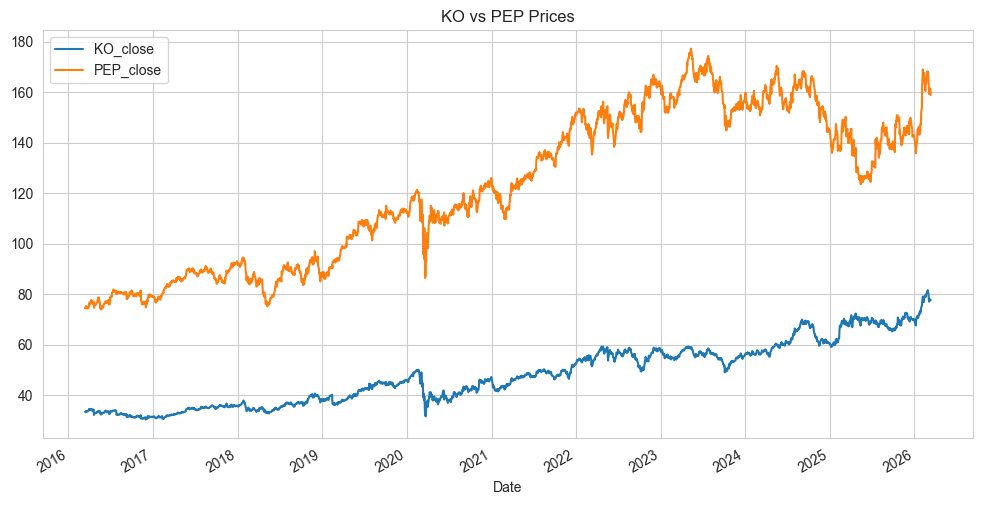

In [10]:
prices[["KO_close", "PEP_close"]].plot(title="KO vs PEP Prices")
plt.show()

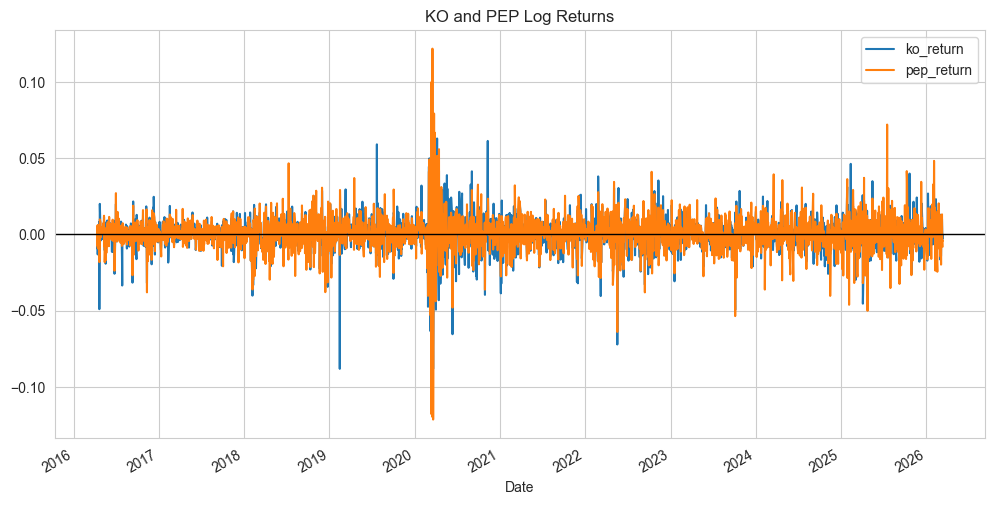

In [11]:
dataset[["ko_return", "pep_return"]].plot(title="KO and PEP Log Returns")
plt.axhline(0, color="black", linewidth=1)
plt.show()

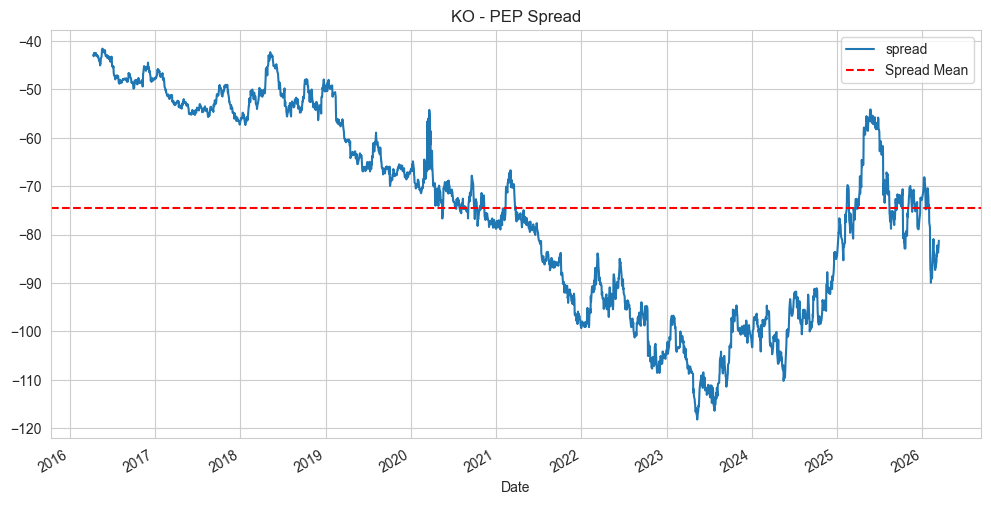

In [12]:
dataset["spread"].plot(title="KO - PEP Spread")
plt.axhline(dataset["spread"].mean(), color="red", linestyle="--", label="Spread Mean")
plt.legend()
plt.show()

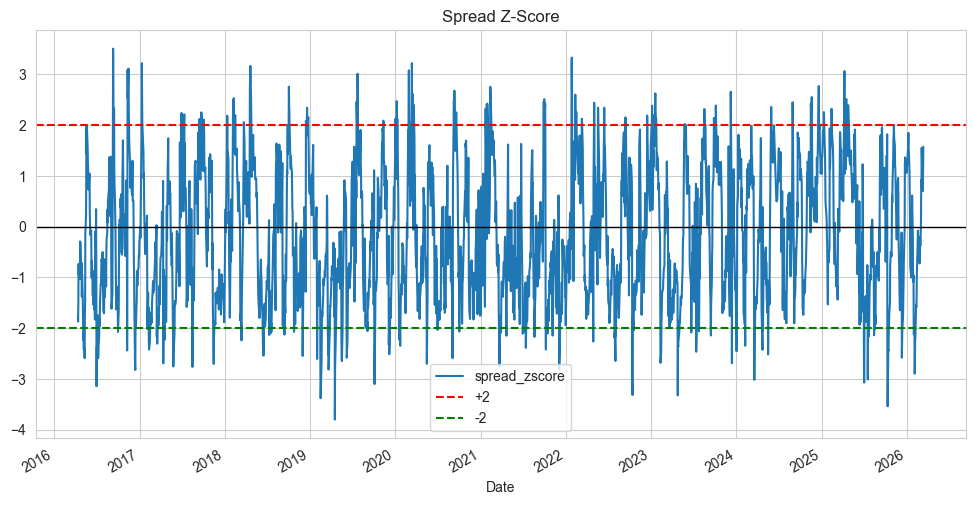

In [13]:
dataset["spread_zscore"].plot(title="Spread Z-Score")
plt.axhline(0, color="black", linewidth=1)
plt.axhline(2, color="red", linestyle="--", label="+2")
plt.axhline(-2, color="green", linestyle="--", label="-2")
plt.legend()
plt.show()

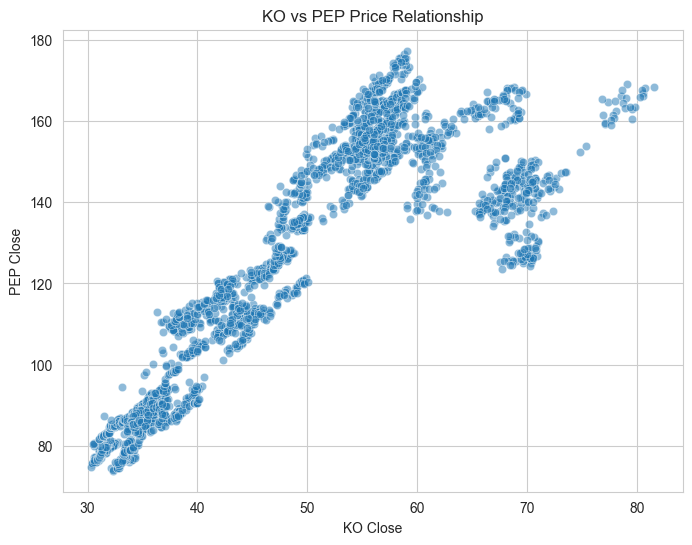

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=dataset["KO_close"], y=dataset["PEP_close"], alpha=0.5)
plt.title("KO vs PEP Price Relationship")
plt.xlabel("KO Close")
plt.ylabel("PEP Close")
plt.show()

In [15]:
corr = dataset[["ko_return", "pep_return"]].corr()
corr

,ko_return,pep_return
ko_return,1.000000,0.718163
pep_return,0.718163,1.000000


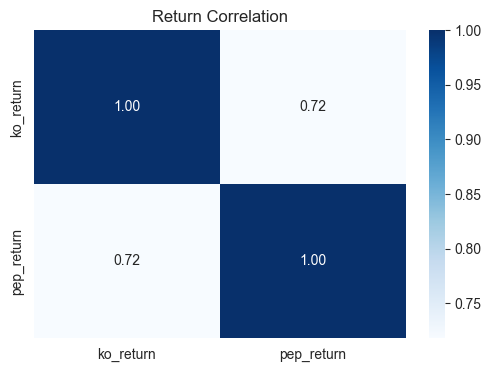

In [16]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Return Correlation")
plt.show()

In [17]:
from pathlib import Path

raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

prices.to_csv(raw_dir / "ko_pep_prices.csv")
dataset.to_csv(processed_dir / "ko_pep_spread_dataset.csv")

print("Saved:")
print(raw_dir / "ko_pep_prices.csv")
print(processed_dir / "ko_pep_spread_dataset.csv")

Saved:
/Users/abhi/Downloads/ml-projects/data/raw/ko_pep_prices.csv
/Users/abhi/Downloads/ml-projects/data/processed/ko_pep_spread_dataset.csv


In [18]:
dataset[["spread", "spread_mean_20", "spread_zscore"]].tail(10)

,spread,spread_mean_20,spread_zscore
Date,,,
2026-02-27,-86.676956,-85.394202,-0.388699
2026-03-02,-85.578735,-85.800158,0.081366
2026-03-03,-84.109726,-86.080860,0.912637
2026-03-04,-84.368492,-86.073386,0.787201
2026-03-05,-82.247009,-85.817813,1.550260
2026-03-06,-82.389992,-85.560486,1.328126
2026-03-09,-83.729996,-85.249470,0.696524
2026-03-10,-82.900002,-85.043175,0.974308
2026-03-11,-82.519997,-84.735100,1.058769
